In [ ]:
#######CLONING DATASET#######

In [ ]:
!git clone https://github.com/TheMLevin/ContourletDiff.git

Cloning into 'ContourletDiff'...
remote: Enumerating objects: 639, done.
remote: Counting objects: 100% (75/75), done.
remote: Compressing objects: 100% (62/62), done.
remote: Total 639 (delta 45), reused 19 (delta 11), pack-reused 564 (from 2)
Receiving objects: 100% (639/639), 219.98 MiB | 16.68 MiB/s, done.
Resolving deltas: 100% (392/392), done.
Updating files: 100% (61/61), done.


In [ ]:
%cd ContourletDiff

/content/ContourletDiff


In [ ]:
#######REQD INSTALLS#######

In [ ]:
!ls

assets			 EMA.py		   run_cddgan.sh   test_wddgan.py
compute_dataset_stat.py  environment.yml   run_ddgan.sh    train_cddgan.py
Contourlet		 LICENSE	   run_wddgan.sh   train_ddgan.py
data			 __pycache__	   saved_info	   train_wddgan.py
datasets_prep		 pytorch_fid	   score_sde	   utils.py
diffusion.py		 readme.md	   test_cddgan.py
DWT_IDWT		 requirements.txt  test_ddgan.py


In [ ]:
!pip install -q -r requirements.txt

In [ ]:
#######INSTALLING WAVELETS#######

In [ ]:
!pip install -q git+https://github.com/fbcotter/pytorch_wavelets.git

  Preparing metadata (setup.py) ... done


In [ ]:
!git checkout sudeshnm
!git reset --hard origin/sudeshnm

Already on 'sudeshnm'
Your branch is up to date with 'origin/sudeshnm'.
HEAD is now at 04e61c7 Refactor ContourletDownsample and ResnetBlock classes


In [ ]:
import torch
print("PyTorch:", torch.__version__)
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

PyTorch: 2.9.0+cu126
GPU: NVIDIA A100-SXM4-40GB


In [ ]:
import torch
torch.cuda.empty_cache()
torch.cuda.ipc_collect()

In [ ]:
!kill -9 -1

In [ ]:
!bash run_cddgan.sh stl10 train 1

MASTER_PORT=12355
The work dir is:  /content/ContourletDiff
stl10 train 1
==> Training ContourletDiff
starting in debug mode
Auto-calculated num_channels for contourlet (nlevs=2): 15
GEN: <class 'score_sde.models.ncsnpp_generator_adagn.ContourletNCSNpp'>, DISC: [<class 'score_sde.models.discriminator.Discriminator_small'>, <class 'score_sde.models.discriminator.Discriminator_large'>]
[rank0]: Traceback (most recent call last):
[rank0]:   File "/content/ContourletDiff/train_cddgan.py", line 479, in <module>
[rank0]:     init_processes(0, size, train, args)
[rank0]:   File "/content/ContourletDiff/utils.py", line 25, in init_processes
[rank0]:     fn(rank, gpu, args)
[rank0]:   File "/content/ContourletDiff/train_cddgan.py", line 79, in train
[rank0]:     netG = gen_net(args).to(device)
[rank0]:            ^^^^^^^^^^^^^^^^^^^^^^^^
[rank0]:   File "/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py", line 1371, in to
[rank0]:     return self._apply(convert)
[rank0]:       

In [ ]:
#######INFERENCE#######

In [ ]:
# Run in /content/WaveDiff
import os, io, zipfile, requests, shutil, glob

exp = "wddgan_cifar10_exp1_noatn_g122_d3_recloss_1800ep"   # exactly as in the error
ckpt_dir = f"saved_info/wdd_gan/cifar10/{exp}"
os.makedirs(ckpt_dir, exist_ok=True)

# CIFAR-10 checkpoint bundle (Dropbox)
url = "https://www.dropbox.com/sh/d1h1b9y0hjptnju/AABCdqJWnTq45uK2SRr6S_qGa?dl=1"

r = requests.get(url); r.raise_for_status()
bio = io.BytesIO(r.content)

if zipfile.is_zipfile(bio):
    with zipfile.ZipFile(bio) as z:
        z.extractall(ckpt_dir)
else:
    with open(os.path.join(ckpt_dir, "netG_1300.pth"), "wb") as f:
        f.write(r.content)

# If the zip created a subfolder, move the .pth up one level
for root, _, files in os.walk(ckpt_dir):
    for f in files:
        if f.endswith(".pth") and root != ckpt_dir:
            shutil.move(os.path.join(root, f), os.path.join(ckpt_dir, f))

print("Checkpoint files:", glob.glob(ckpt_dir + "/*.pth"))

Checkpoint files: ['saved_info/wdd_gan/cifar10/wddgan_cifar10_exp1_noatn_g122_d3_recloss_1800ep/netG_1300.pth']


In [ ]:

from pathlib import Path
import re

dataset = "cifar10"
exp = "wddgan_cifar10_exp1_noatn_g122_d3_recloss_1800ep"   # <- use the real folder name

p = Path("run_wddgan.sh")
txt = p.read_text()

# Force the cifar10 TEST branch to use the correct exp folder
patched = re.sub(
    rf"(\b{dataset}\b.*?--mode\s+test.*?--exp\s+)(\S+)",
    rf"\1{exp}",
    txt,
    flags=re.DOTALL
)
p.write_text(patched)
print("run_wddgan.sh patched for", dataset, "test → --exp", exp)

run_wddgan.sh patched for cifar10 test → --exp wddgan_cifar10_exp1_noatn_g122_d3_recloss_1800ep


In [ ]:
# from /content/Contourlet
!bash run_wddgan.sh cifar10 test 1

MASTER_PORT=6036
The work dir is:  /content/ContourletDiff
cifar10 test 1
==> Testing WaveDiff
16 [1, 2, 2] [32]
GEN: <class 'score_sde.models.ncsnpp_generator_adagn.NCSNpp'>
Traceback (most recent call last):
  File "/content/ContourletDiff/test_wddgan.py", line 236, in <module>
    sample_and_test(args)
  File "/content/ContourletDiff/test_wddgan.py", line 41, in sample_and_test
    netG = gen_net(args).to(device)
           ^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py", line 1371, in to
    return self._apply(convert)
           ^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py", line 930, in _apply
    module._apply(fn)
  File "/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py", line 930, in _apply
    module._apply(fn)
  File "/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py", line 957, in _apply
    param_applied = fn(param)
                    ^

In [ ]:
!python test_cddgan.py \
  --dataset cifar10 \
  --exp cddgan_cifar10_exp1_noatn_g122_d3_recloss_1800ep \
  --epoch_id 200 \
  --image_size 32 --current_resolution 16 --attn_resolutions 32 \
  --num_channels_dae 128 --num_timesteps 4 \
  --nz 100 --z_emb_dim 256 --n_mlp 4 --ch_mult 1 2 2 --epoch_id 200 \
  --batch_size 100 \
  --compute_fid --real_img_dir pytorch_fid/cifar10_train_stat.npy

Auto-calculated num_channels for contourlet (nlevs=2): 15
16 [1, 2, 2] [32]
GEN: <class 'score_sde.models.ncsnpp_generator_adagn.NCSNpp'>
generating batch  0
generating batch  1
generating batch  2
generating batch  3
generating batch  4
generating batch  5
generating batch  6
generating batch  7
generating batch  8
generating batch  9
generating batch  10
generating batch  11
generating batch  12
generating batch  13
generating batch  14
generating batch  15
generating batch  16
generating batch  17
generating batch  18
generating batch  19
generating batch  20
generating batch  21
generating batch  22
generating batch  23
generating batch  24
generating batch  25
generating batch  26
generating batch  27
generating batch  28
generating batch  29
generating batch  30
generating batch  31
generating batch  32
generating batch  33
generating batch  34
generating batch  35
generating batch  36
generating batch  37
generating batch  38
generating batch  39
generating batch  40
generating 

In [ ]:
!python test_wddgan.py --dataset cifar10 --exp wddgan_cifar10_exp1_noatn_g122_d3_recloss_1800ep --num_channels 12 --num_channels_dae 128 --num_timesteps 4 \
			--num_res_blocks 2 --nz 100 --z_emb_dim 256 --n_mlp 4 --ch_mult 1 2 2 --epoch_id 0 \
			--image_size 32 --current_resolution 16 --attn_resolutions 32 \
			--use_pytorch_wavelet

16 [1, 2, 2] [32]
GEN: <class 'score_sde.models.ncsnpp_generator_adagn.NCSNpp'>
Results are saved at samples_cifar10.jpg


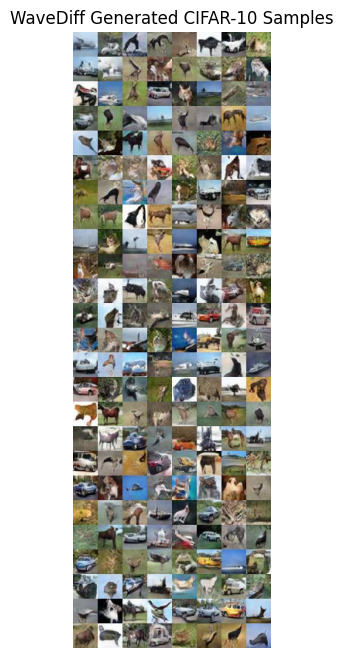

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("samples_cifar10.jpg")

plt.figure(figsize=(8,8))
plt.imshow(img)
plt.axis("off")
plt.title("WaveDiff Generated CIFAR-10 Samples")
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
#######TRAINING#######

In [ ]:
from pathlib import Path
import re

p = Path("train_cddgan.py")
s = p.read_text()

# Save: replace ... 'optimizerG': optimizerG.state_dict(), ...
s = s.replace(
    "'optimizerG': optimizerG.state_dict(),",
    "'optimizerG': (getattr(optimizerG, 'optimizer', optimizerG).state_dict()),"
)

p.write_text(s)
print("Patched saving: will store inner optimizer state if using EMA.")

Patched saving: will store inner optimizer state if using EMA.


In [ ]:
!bash run_wddgan.sh cifar10 train 1
#!bash run_cddgan.sh stl10 train 1

MASTER_PORT=6036
The work dir is:  /content/ContourletDiff
cifar10 train 1
==> Training WaveDiff
starting in debug mode
GEN: <class 'score_sde.models.ncsnpp_generator_adagn.NCSNpp'>, DISC: [<class 'score_sde.models.discriminator.Discriminator_small'>, <class 'score_sde.models.discriminator.Discriminator_large'>]
[rank0]:[W1207 00:10:43.831323055 reducer.cpp:1431] Warning: find_unused_parameters=True was specified in DDP constructor, but did not find any unused parameters in the forward pass. This flag results in an extra traversal of the autograd graph every iteration,  which can adversely affect performance. If your model indeed never has any unused parameters in the forward pass, consider turning this flag off. Note that this warning may be a false positive if your model has flow control causing later iterations to have unused parameters. (function operator())
epoch 0 iteration0, G Loss: 5.949857711791992, D Loss: 1.3862942457199097
epoch 0 iteration100, G Loss: 0.6890256404876709, D

In [ ]:
!python test_cddgan.py \
  --dataset cifar10 \
  --exp cddgan_cifar10_exp1_noatn_g122_d3_recloss_1800ep \
  --epoch_id 0 \
  --image_size 32 --current_resolution 16 --attn_resolutions 32 \
  --num_channels_dae 128 --num_timesteps 4 \
  --nz 100 --z_emb_dim 256 --n_mlp 4 --ch_mult 1 2 2 \
  --batch_size 100 \
  --compute_fid --real_img_dir pytorch_fid/cifar10_train_stat.npy

Auto-calculated num_channels for contourlet (nlevs=2): 15
16 [1, 2, 2] [32]
GEN: <class 'score_sde.models.ncsnpp_generator_adagn.NCSNpp'>
generating batch  0
generating batch  1
generating batch  2
generating batch  3
generating batch  4
generating batch  5
generating batch  6
generating batch  7
generating batch  8
generating batch  9
generating batch  10
generating batch  11
generating batch  12
generating batch  13
generating batch  14
generating batch  15
generating batch  16
generating batch  17
generating batch  18
generating batch  19
generating batch  20
generating batch  21
generating batch  22
generating batch  23
generating batch  24
generating batch  25
generating batch  26
generating batch  27
generating batch  28
generating batch  29
generating batch  30
generating batch  31
generating batch  32
generating batch  33
generating batch  34
generating batch  35
generating batch  36
generating batch  37
generating batch  38
generating batch  39
generating batch  40
generating 

In [ ]:
!python test_cddgan.py \
  --dataset cifar10 \
  --exp cddgan_cifar10_exp1_noatn_g122_d3_recloss_1800ep \
  --epoch_id 200 \
  --image_size 32 --current_resolution 16 --attn_resolutions 32 \
  --num_channels_dae 128 --num_timesteps 4 \
  --nz 100 --z_emb_dim 256 --n_mlp 4 --ch_mult 1 2 2 \
  --batch_size 100 \
  --measure_time --real_img_dir pytorch_fid/cifar10_train_stat.npy

Auto-calculated num_channels for contourlet (nlevs=2): 15
16 [1, 2, 2] [32]
GEN: <class 'score_sde.models.ncsnpp_generator_adagn.NCSNpp'>
Inference time: 93.76+/-3.42ms


In [ ]:
from pathlib import Path
import re

p = Path("train_wddgan.py")
s = p.read_text()

# Save: replace ... 'optimizerG': optimizerG.state_dict(), ...
s = s.replace(
    "'optimizerG': optimizerG.state_dict(),",
    "'optimizerG': (getattr(optimizerG, 'optimizer', optimizerG).state_dict()),"
)

p.write_text(s)
print("Patched saving: will store inner optimizer state if using EMA.")

Patched saving: will store inner optimizer state if using EMA.


In [ ]:
!pip install torchtoolbox

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 7.1 MB/s eta 0:00:00


In [ ]:
!bash run_wddgan.sh cifar10 train 1

MASTER_PORT=6036
The work dir is:  /content/ContourletDiff
cifar10 train 1
==> Training WaveDiff
starting in debug mode
GEN: <class 'score_sde.models.ncsnpp_generator_adagn.NCSNpp'>, DISC: [<class 'score_sde.models.discriminator.Discriminator_small'>, <class 'score_sde.models.discriminator.Discriminator_large'>]
[rank0]:[W1206 19:52:05.608338208 reducer.cpp:1431] Warning: find_unused_parameters=True was specified in DDP constructor, but did not find any unused parameters in the forward pass. This flag results in an extra traversal of the autograd graph every iteration,  which can adversely affect performance. If your model indeed never has any unused parameters in the forward pass, consider turning this flag off. Note that this warning may be a false positive if your model has flow control causing later iterations to have unused parameters. (function operator())
epoch 0 iteration0, G Loss: 5.949857711791992, D Loss: 1.3862942457199097
epoch 0 iteration100, G Loss: 0.6890256404876709, D

In [ ]:
#!bash run_wddgan.sh lsun train 1 #lsun church thing

MASTER_PORT=6036
The work dir is:  /content/ContourletDiff
lsun train 1
==> Training WaveDiff
starting in debug mode
[rank0]: Traceback (most recent call last):
[rank0]:   File "/content/ContourletDiff/train_wddgan.py", line 444, in <module>
[rank0]:     init_processes(0, size, train, args)
[rank0]:   File "/content/ContourletDiff/utils.py", line 25, in init_processes
[rank0]:     fn(rank, gpu, args)
[rank0]:   File "/content/ContourletDiff/train_wddgan.py", line 48, in train
[rank0]:     dataset = create_dataset(args)
[rank0]:               ^^^^^^^^^^^^^^^^^^^^
[rank0]:   File "/content/ContourletDiff/datasets_prep/dataset.py", line 50, in create_dataset
[rank0]:     train_data = LSUN(root=args.datadir, classes=[
[rank0]:                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
[rank0]:   File "/content/ContourletDiff/datasets_prep/lsun.py", line 93, in __init__
[rank0]:     self.dbs.append(LSUNClass(
[rank0]:                     ^^^^^^^^^^
[rank0]:   File "/content/ContourletDiff/datasets_

In [ ]:
!python test_wddgan.py \
  --dataset cifar10 \
  --exp wddgan_cifar10_exp1_noatn_g122_d3_recloss_1800ep \
  --epoch_id 200 \
  --image_size 32 --current_resolution 16 --attn_resolutions 32 \
  --num_channels_dae 128 --num_timesteps 4 \
  --nz 100 --z_emb_dim 256 --n_mlp 4 --ch_mult 1 2 2 \
  --batch_size 100 \
  --compute_fid --real_img_dir pytorch_fid/cifar10_train_stat.npy

16 [1, 2, 2] [32]
GEN: <class 'score_sde.models.ncsnpp_generator_adagn.NCSNpp'>
generating batch  0
generating batch  1
generating batch  2
generating batch  3
generating batch  4
generating batch  5
generating batch  6
generating batch  7
generating batch  8
generating batch  9
generating batch  10
generating batch  11
generating batch  12
generating batch  13
generating batch  14
generating batch  15
generating batch  16
generating batch  17
generating batch  18
generating batch  19
generating batch  20
generating batch  21
generating batch  22
generating batch  23
generating batch  24
generating batch  25
generating batch  26
generating batch  27
generating batch  28
generating batch  29
generating batch  30
generating batch  31
generating batch  32
generating batch  33
generating batch  34
generating batch  35
generating batch  36
generating batch  37
generating batch  38
generating batch  39
generating batch  40
generating batch  41
generating batch  42
generating batch  43
genera

In [ ]:
!python test_wddgan.py \
  --dataset cifar10 \
  --exp wddgan_cifar10_exp1_noatn_g122_d3_recloss_1800ep \
  --epoch_id 50 \
  --image_size 32 --current_resolution 16 --attn_resolutions 32 \
  --num_channels_dae 128 --num_timesteps 4 \
  --nz 100 --z_emb_dim 256 --n_mlp 4 --ch_mult 1 2 2 \
  --batch_size 100 \
  --measure_time --real_img_dir pytorch_fid/cifar10_train_stat.npy

16 [1, 2, 2] [32]
GEN: <class 'score_sde.models.ncsnpp_generator_adagn.NCSNpp'>
Inference time: 89.17+/-1.07ms


In [ ]:
# set your experiment folder (the one used by run.sh)
# EXP="wddgan_cifar10_exp1_noatn_g122_d3_recloss_1800ep"
# EPOCH=25

# """!python test_wddgan.py \
#   --dataset cifar10 \
#   --exp $EXP \
#   --epoch_id $EPOCH \
#   --image_size 32 --current_resolution 16 --attn_resolutions 32 \
#   --num_channels 12 --num_channels_dae 128 --num_timesteps 4 \
#   --nz 100 --z_emb_dim 256 --n_mlp 4 --ch_mult 1 2 2 \
#   --use_pytorch_wavelet \
#   --batch_size 100 \
#   --compute_fid --real_img_dir pytorch_fid/cifar10_train_stat.npy"""



# !python test_wddgan.py \
#   --dataset cifar10 \
#   --exp wddgan_cifar10_exp1_noatn_g122_d3_recloss_1800ep \
#   --epoch_id 1300 \
#   --image_size 32 --current_resolution 16 --attn_resolutions 32 \
#   --num_channels 12 --num_channels_dae 128 --num_timesteps 4 \
#   --nz 100 --z_emb_dim 256 --n_mlp 4 --ch_mult 1 2 2 \
#   --use_pytorch_wavelet \
#   --batch_size 100 \
#   --compute_fid --real_img_dir pytorch_fid/cifar10_train_stat.npy
# For the trained model (dataset) to 1300 epochs

## replace with --measure_time to measure compute time

16 [1, 2, 2] [32]
GEN: <class 'score_sde.models.ncsnpp_generator_adagn.NCSNpp'>
generating batch  0
generating batch  1
generating batch  2
generating batch  3
generating batch  4
generating batch  5
generating batch  6
generating batch  7
generating batch  8
generating batch  9
generating batch  10
generating batch  11
generating batch  12
generating batch  13
generating batch  14
generating batch  15
generating batch  16
generating batch  17
generating batch  18
generating batch  19
generating batch  20
generating batch  21
generating batch  22
generating batch  23
generating batch  24
generating batch  25
generating batch  26
generating batch  27
generating batch  28
generating batch  29
generating batch  30
generating batch  31
generating batch  32
generating batch  33
generating batch  34
generating batch  35
generating batch  36
generating batch  37
generating batch  38
generating batch  39
generating batch  40
generating batch  41
generating batch  42
generating batch  43
genera

In [ ]:
# FID with wavelet generator: 15.00968257877264